# Calculating spectra and Roman magnitudes for Galacticus galaxies

This notebook demonstrates the main `galacticus_sed_calculator` workflow using
the small Galacticus lightcone and SED template included in the repository. It
shows how to inspect a galaxy, calculate its observed spectrum, apply a simple
dust model, and integrate the spectrum through Roman WFI filters.

## Set up the example

The SED calculator needs a Galacticus catalog, a compatible SED template, and
the cosmology used to generate the catalog. This example uses the UNIT
cosmology associated with the bundled lightcone.

In [1]:
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import LambdaCDM

from galacticus_sed_calculator import SEDCalculator

repository_root = Path.cwd()
if not (repository_root / "pyproject.toml").exists():
    repository_root = repository_root.parent

catalog = repository_root / "data/romanUNIT.hdf5"
template = repository_root / "data/nodePropertyExtractorSED_Nt50_NZ11_ageMinimum0.001.hdf5"
unit_cosmology = LambdaCDM(H0=67.74, Om0=0.3089, Ode0=0.6911)

calculator = SEDCalculator(template, cosmology=unit_cosmology)
galaxy_index = 0
galaxy = calculator.read_galacticus_galaxy(catalog, galIndex=galaxy_index)

print(f"Galaxy index: {galaxy_index}")
print(f"Redshift: {galaxy['redshift']:.3f}")

Galaxy index: 0
Redshift: 1.442


## Calculate the observed spectrum

Galacticus records separate star formation histories and emission-line
luminosities for the disk and spheroid. The calculator can return either
stellar component separately or their total spectrum, including any AGN
emission lines. The AGN spectrum is not plotted separately because Galacticus
does not provide an AGN continuum in this example. The result is a
`synphot.SourceSpectrum`, which can be evaluated on any suitable wavelength
grid.

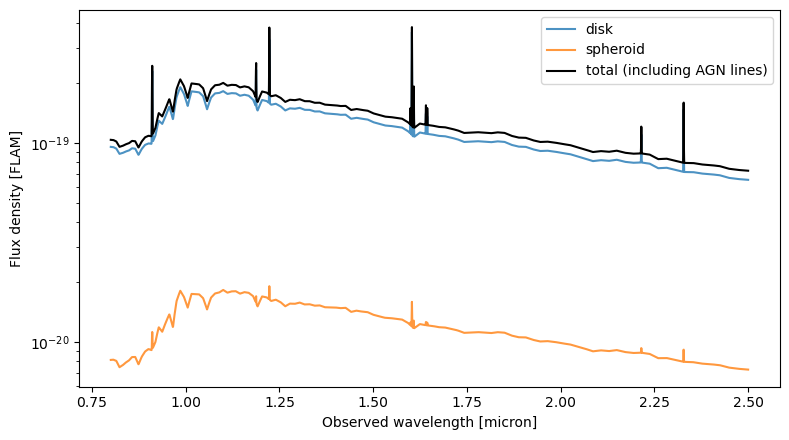

In [2]:
observed_wavelength = np.linspace(8000, 25000, 3000) * u.AA

component_spectra = {
    component: calculator.evaluate_component_spectrum(
        catalog,
        galIndex=galaxy_index,
        component=component,
        obs_wavelengths=observed_wavelength,
    )
    for component in ("disk", "spheroid")
}
total_spectrum = calculator.evaluate_total_spectrum(
    catalog,
    galIndex=galaxy_index,
    obs_wavelengths=observed_wavelength,
)

fig, ax = plt.subplots(figsize=(8, 4.5))
for component, spectrum in component_spectra.items():
    ax.plot(
        observed_wavelength.to_value(u.micron),
        spectrum(observed_wavelength, flux_unit="flam"),
        label=component,
        alpha=0.8,
    )
ax.plot(
    observed_wavelength.to_value(u.micron),
    total_spectrum(observed_wavelength, flux_unit="flam"),
    color="black",
    label="total (including AGN lines)",
    linewidth=1.5,
)
ax.set(xlabel="Observed wavelength [micron]", ylabel="Flux density [FLAM]")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()

Emission lines are represented internally at adaptive resolution by
`synphot`. Evaluating the returned spectrum on a very coarse regular grid can
therefore undersample narrow lines. Use a sufficiently fine wavelength grid
when exporting spectra for another calculation.

## Check that the SED template is compatible

The age and metallicity bins in the template must match those used to save the
galaxy star formation histories. The repository includes an intentionally
incompatible template so that this check can be demonstrated.

In [3]:
incompatible_template = repository_root / "data/nodePropertyExtractorSED_Nt50_NZ11_ageMinimum0.003.hdf5"
incompatible_calculator = SEDCalculator(
    incompatible_template,
    cosmology=unit_cosmology,
)

try:
    incompatible_calculator.evaluate_total_spectrum(
        catalog,
        galIndex=galaxy_index,
        obs_wavelengths=observed_wavelength,
    )
except ValueError as error:
    print(error)

SED template and star formation history are incompatible:
  ageMinimum mismatch: SFH=0.001, SED template=0.0030000000000004468


## Apply dust attenuation

Emission-line and stellar-continuum attenuation are configured separately.
The emission-line model below depends on stellar mass and redshift; its scatter
is set to zero so that the example is deterministic. We then add an
illustrative fixed continuum attenuation of $A_V=1$ using the Calzetti law.
These parameter values demonstrate the interface and are not intended to be
universal dust parameters.

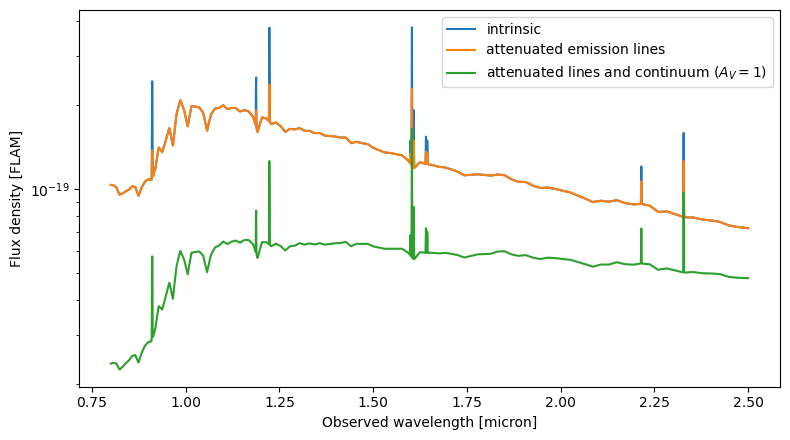

In [4]:
dust_parameters = {
    "delta_0": 0.275,
    "delta_z": -1.614,
    "delta_M": -0.834,
    "delta_Mz": -0.708,
    "attenuation_scatter": 0.0,
}
continuum_dust = {
    "model": "fixed_av",
    "params": {"A_V": 1.0},
    "law": "calzetti",
}

line_attenuated_spectrum = calculator.evaluate_total_spectrum(
    catalog,
    galIndex=galaxy_index,
    obs_wavelengths=observed_wavelength,
    dust_model="gb10_generalised",
    dust_params=dust_parameters,
    dust_law="calzetti",
)
line_and_continuum_attenuated_spectrum = calculator.evaluate_total_spectrum(
    catalog,
    galIndex=galaxy_index,
    obs_wavelengths=observed_wavelength,
    dust_model="gb10_generalised",
    dust_params=dust_parameters,
    dust_law="calzetti",
    continuum_dust=continuum_dust,
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    observed_wavelength.to_value(u.micron),
    total_spectrum(observed_wavelength, flux_unit="flam"),
    label="intrinsic",
)
ax.plot(
    observed_wavelength.to_value(u.micron),
    line_attenuated_spectrum(observed_wavelength, flux_unit="flam"),
    label="attenuated emission lines",
)
ax.plot(
    observed_wavelength.to_value(u.micron),
    line_and_continuum_attenuated_spectrum(
        observed_wavelength,
        flux_unit="flam",
    ),
    label=r"attenuated lines and continuum ($A_V=1$)",
)
ax.set(xlabel="Observed wavelength [micron]", ylabel="Flux density [FLAM]")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()

## Calculate Roman WFI magnitudes

STPSF provides the Roman WFI filter transmission curves. Load each bandpass
once and reuse it when processing multiple galaxies.

In [5]:
import stpsf

roman_filters = ["F062", "F087", "F106", "F129", "F158", "F184", "F213"]
roman = stpsf.WFI()
bandpasses = {
    filter_name: roman._get_synphot_bandpass(filter_name)
    for filter_name in roman_filters
}

magnitudes = calculator.calculate_magnitudes(
    catalog,
    galIndex=galaxy_index,
    bandpasses=bandpasses,
    component="total",
    magnitude_system="AB",
    obs_wavelengths=np.linspace(3000, 30000, 2000) * u.AA,
)

for filter_name, magnitude in magnitudes.items():
    print(f"{filter_name}: {magnitude:.3f}")

F062: 26.181
F087: 25.183
F106: 24.290
F129: 23.991
F158: 23.802
F184: 23.674
F213: 23.553


For catalog-scale work, `scripts/calculate_catalog_magnitudes.py`
applies the same calculation to every galaxy, reads the cosmology from the
Galacticus file, supports parallel processing, and records the calculation
settings in the output.